In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

In [3]:
df = pd.read_csv("Well production analysis data.csv")

In [5]:
#preprocessing

df["DATEPRD"] = pd.to_datetime(df["DATEPRD"], format="%d-%b-%y")

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df["FLOW_KIND"] = df["FLOW_KIND"].fillna("Unknown")

In [6]:
#feature engineering

df["Pressure_Diff"] = df["AVG_DOWNHOLE_PRESSURE"] - df["AVG_WHP_P"]

df["Temp_Diff"] = df["AVG_DOWNHOLE_TEMPERATURE"] - df["AVG_WHT_P"]

In [7]:
features = [
    "ON_STREAM_HRS",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_DP_TUBING",
    "AVG_ANNULUS_PRESS",
    "AVG_CHOKE_SIZE_P",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "Pressure_Diff",
    "Temp_Diff"
]

X = df[features]

y = df["BORE_OIL_VOL"]

In [27]:
#supervised
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Features
features = [
    "ON_STREAM_HRS",
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_DP_TUBING",
    "AVG_ANNULUS_PRESS",
    "AVG_CHOKE_SIZE_P",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "Pressure_Diff",
    "Temp_Diff"
]

X = df[features]
y = df["BORE_OIL_VOL"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 Score": r2_score(y_test, pred)
    })

results = pd.DataFrame(results)

results = results.sort_values("R2 Score", ascending=False)

print(results)

               Model         MAE        RMSE  R2 Score
4                KNN   41.213431  135.355344  0.983509
2      Random Forest   40.537948  140.738268  0.982172
1      Decision Tree   47.948848  176.423517  0.971985
3  Gradient Boosting  101.962932  237.408036  0.949269
0  Linear Regression  543.513977  838.553568  0.367084
5                SVR  422.551513  956.786983  0.176023


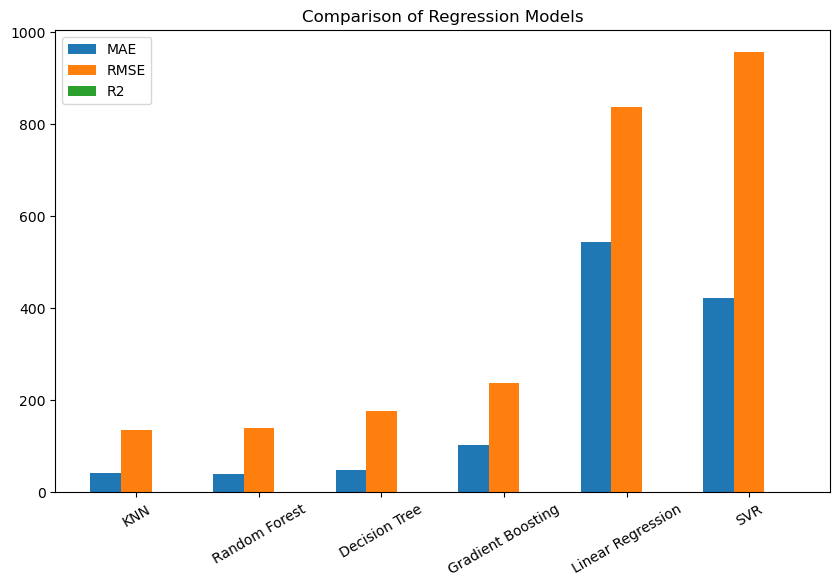

In [28]:
#Comparison Plot

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(results))

width = 0.25

ax.bar(x-width, results["MAE"], width, label="MAE")
ax.bar(x, results["RMSE"], width, label="RMSE")
ax.bar(x+width, results["R2 Score"], width, label="R2")

ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=30)

plt.legend()

plt.title("Comparison of Regression Models")

plt.show()

In [29]:
#Unsupervised Comparison
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

cluster_features = [
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_WHP_P",
    "AVG_WHT_P",
    "BORE_OIL_VOL"
]

cluster_data = StandardScaler().fit_transform(df[cluster_features])

algorithms = {
    "KMeans": KMeans(n_clusters=3, random_state=42),
    "Agglomerative": AgglomerativeClustering(n_clusters=3),
    "DBSCAN": DBSCAN(eps=0.8, min_samples=10)
}

cluster_results = []

for name, algo in algorithms.items():

    labels = algo.fit_predict(cluster_data)

    if len(set(labels)) > 1 and -1 not in set(labels):

        score = silhouette_score(cluster_data, labels)

    else:

        score = np.nan

    cluster_results.append([name, score])

cluster_results = pd.DataFrame(
    cluster_results,
    columns=["Algorithm","Silhouette Score"]
)

print(cluster_results)

       Algorithm  Silhouette Score
0         KMeans          0.512412
1  Agglomerative          0.637858
2         DBSCAN               NaN


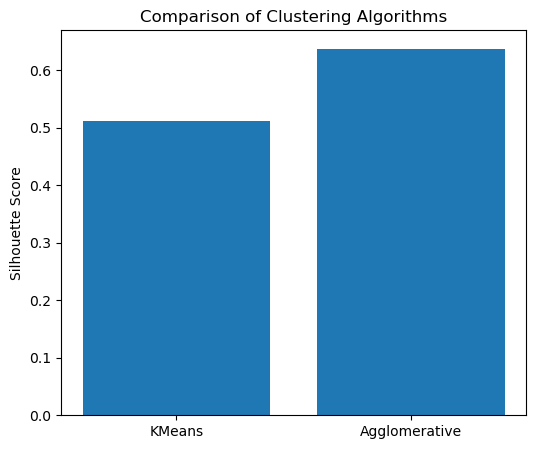

In [30]:
plt.figure(figsize=(6,5))

plt.bar(
    cluster_results["Algorithm"],
    cluster_results["Silhouette Score"]
)

plt.ylabel("Silhouette Score")

plt.title("Comparison of Clustering Algorithms")

plt.show()